# Práctica con COCO128
COCO128 es un pequeño dataset de detección de objetos formado por 128 imágenes tomadas del conjunto COCO train2017, preparado por Ultralytics como dataset de tutorial y pruebas rápidas. Con esta libreria realizaremos una serie de ejercicios

En primer lugar, deberemos de importar la libreria de YOLO

In [1]:
from ultralytics import YOLO
import os

# Comprobación rápida de que se ha importado bien
print("Versión de Ultralytics instalada:")
import ultralytics
print(ultralytics.__version__)

Versión de Ultralytics instalada:
8.3.235


## Entrenamiento rápido con COCO128

Este bloque carga un modelo YOLO11 pequeño (`yolo11n.pt`) y entrena unas pocas épocas sobre el dataset COCO128.
COCO128 es un subconjunto de 128 imágenes de COCO preparado por Ultralytics para pruebas rápidas; al usar `data="coco128.yaml"` se descarga automáticamente si no lo tienes.

In [2]:
# Cargar un modelo YOLO11 pequeño preentrenado en COCO
model = YOLO("yolo11l.pt")  # modelo nano para ir rápido

# Entrenamiento rápido de prueba sobre COCO128
results = model.train(
    data="coco128.yaml",    # Ultralytics descargará COCO128 si no lo tienes
    epochs=30,               # ejercicio: prueba luego con 10, 20...
    imgsz=640,
    batch=16,
    project="coco128_practica",
    name="exp_basica",
    verbose=True
)

# Mostrar dónde se han guardado los resultados
print(f"Carpeta de resultados: {results.save_dir}")

Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11l.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=exp_basica6, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, p

## Evaluación e inferencia sobre imágenes

En esta sección se evalúa el modelo entrenado sobre el conjunto de validación de COCO128 y se generan predicciones sobre una imagen de ejemplo.

In [4]:
from pathlib import Path

# 1) Evaluación en COCO128 (val)
metrics = model.val(
    data="coco128.yaml",
    imgsz=640
)

print("Métricas principales:")
for k, v in metrics.results_dict.items():
    print(f"{k}: {v}")

# 2) Inferencia sobre una imagen de ejemplo (fuera del dataset)
sample_image = "https://ultralytics.com/images/bus.jpg"

preds = model.predict(
    source=sample_image,
    imgsz=640,
    conf=0.25,
    save=True  # guarda las imágenes con bounding boxes
)

print("Resultados de inferencia guardados en:")
print(preds[0].save_dir)

# 3) Ejercicio: prueba a hacer inferencia sobre varias imágenes a la vez
# por ejemplo, una carpeta local:
# preds = model.predict(source="mis_imagenes/*.jpg", imgsz=640, conf=0.3, save=True)

Ultralytics 8.3.235 🚀 Python-3.10.19 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 3060, 12044MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2573.1±976.6 MB/s, size: 44.7 KB)
val: Scanning /home/ciabd10/Descargas/MIA/Actividad 1/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 241.2Kit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.8it/s 2.1s0.3s
                   all        128        929      0.936       0.89      0.942      0.832
                person         61        254      0.986      0.814      0.937      0.792
               bicycle          3          6      0.941      0.833      0.851      0.638
                   car         12         46      0.997        0.5      0.777      0.488
            motorcycle          4          5      0.935          1      0.995      0.942
              airplane          5          6      0.943          1 

# Analizar mejor los resultados de inferencia

Carga las imagenes y comprueba lo que ha entrenado

Mostrando resultados de: /home/ciabd10/Descargas/MIA/Actividad 2/runs/detect/predict2


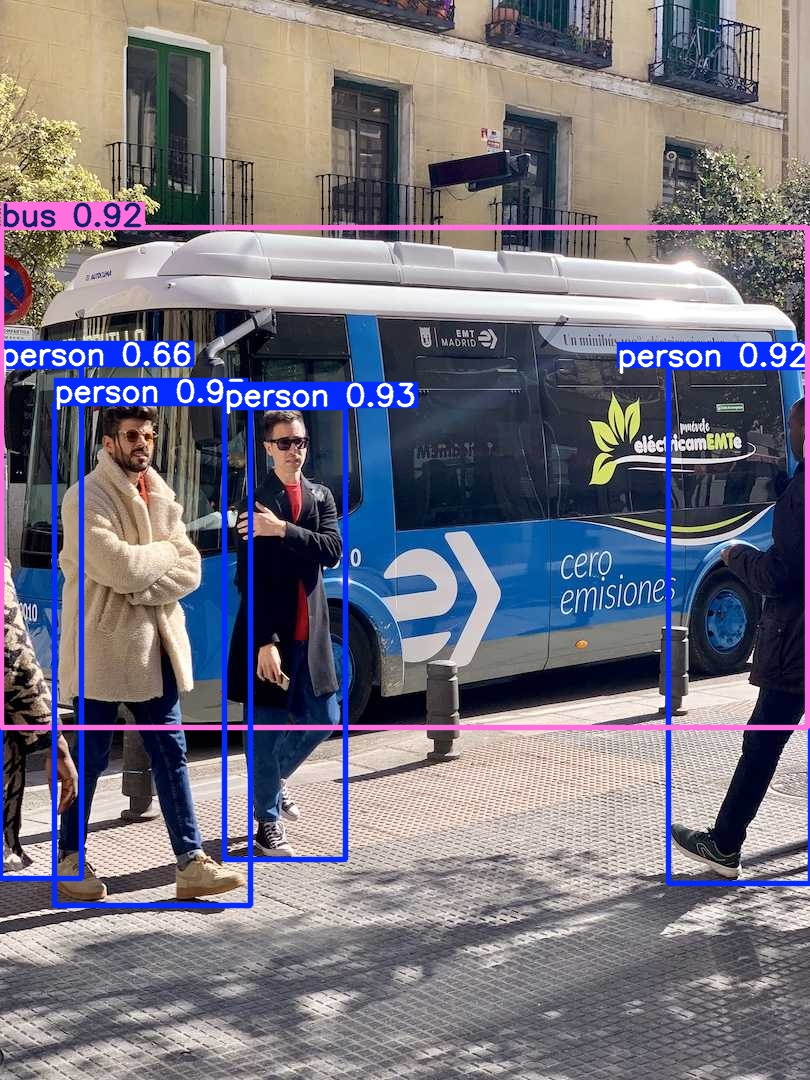

In [6]:
from IPython.display import Image, display
import glob, os

pred_dir = preds[0].save_dir  # carpeta creada por predict
print("Mostrando resultados de:", pred_dir)

for img_path in glob.glob(os.path.join(pred_dir, "*.jpg")):
    display(Image(filename=img_path))


# Exportar el modelo entrenado para usarlo en otro ambito
Para ello necesitaremos instalar esta libreria

In [8]:
%pip install onx

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 4.8 MB/s eta 0:00:005.2 MB/s eta 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 653.6/653.6 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 865.8/865.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 641.0/641.0 kB 2.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for aiohttp (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [117 lines of output]
      *********************
      * Accelerated build *
      *********************
      /tmp/pip-build-env-i4l__zvp/overlay/lib/python3.13/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers are deprecated.
      !!
      
              **************************************************

In [9]:
from ultralytics import YOLO

best_model = YOLO("coco128_practica/exp_basica/weights/best.pt")  # ajusta la ruta
best_model.export(format="onnx")  # genera un best.onnx en la misma carpeta


Ultralytics 8.3.234 🚀 Python-3.13.5 torch-2.9.1+cu128 CPU (11th Gen Intel Core i7-11700F @ 2.50GHz)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'coco128_practica/exp_basica/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.3 MB)

ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.78...
ONNX: export success ✅ 0.9s, saved as 'coco128_practica/exp_basica/weights/best.onnx' (10.2 MB)

Export complete (1.0s)
Results saved to /home/ciabd10/Descargas/MIA/Actividad 2/coco128_practica/exp_basica/weights
Predict:         yolo predict task=detect model=coco128_practica/exp_basica/weights/best.onnx imgsz=640  
Validate:        yolo val task=detect model=coco128_practica/exp_basica/weights/best.onnx imgsz=640 data=/home/ciabd10/anaconda3/lib/python3.13/site-packages/ultralytics/cfg/datasets/coco128.yaml  
Visualize:       https://netron.app


'coco128_practica/exp_basica/weights/best.onnx'